After `bash ./code/data/cloudsen12plus/download_cloudsen12plus_p509.sh`

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VAL_MLSTAC = Path("../data/cloudsen12plus/cloudsen12plus_p509/validation/validation_509_high.mlstac")
assert VAL_MLSTAC.exists(), f"Missing: {VAL_MLSTAC}"

import mlstac
val_df = mlstac.core.load_metadata(str(VAL_MLSTAC))

print("val_df type:", type(val_df))
print("val_df shape:", val_df.shape)
val_df.head()

val_df type: <class 'pandas.DataFrame'>
val_df shape: (535, 3)


,datapoint_id,begin,length
0,ROI_0009__20190513T180929_20190513T181344_T12SWH,0,2597002
1,ROI_0009__20190528T180921_20190528T182048_T12SWH,2597002,2470639
2,ROI_0009__20191027T180439_20191027T180526_T12SWH,5067641,2759093
3,ROI_0009__20200212T181451_20200212T181553_T12SWH,7826734,2849830
4,ROI_0009__20200603T175909_20200603T181313_T12SWH,10676564,2624334


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

LABEL_NAMES = {0: "clear", 1: "thick-cloud", 2: "thin-cloud", 3: "cloud-shadow"}

def load_datapoint(df, idx: int):
    """
    Returns: datapoint array with shape [C,H,W]
    CloudSEN12+ convention: bands 0..12 are S2 bands, 13=CM1 (human), 14=CM2 (model). :contentReference[oaicite:2]{index=2}
    """
    subset = df.iloc[idx:idx+1]
    out = mlstac.core.load_data(subset)
    if isinstance(out, np.ndarray):
        if out.ndim == 4:
            return out[0]
        return out
    if isinstance(out, list):
        first = out[0]
        if isinstance(first, tuple):
            data, _meta = first
            return data
        return first
    raise TypeError(f"Unexpected load_data output type: {type(out)}")

def plot_rgb_mask_overlay(datapoint, alpha=0.45):
    """
    datapoint: [C,H,W]
    RGB: indices [3,2,1] -> B04,B03,B02, scaled by /5000 (as in README). :contentReference[oaicite:3]{index=3}
    Mask (human): index 13 -> CM1. :contentReference[oaicite:4]{index=4}
    """
    rgb = np.moveaxis(datapoint[[3, 2, 1]], 0, -1) / 5000.0
    rgb = np.clip(rgb, 0, 1)

    mask = datapoint[13].astype(np.uint8)

    vals, cnts = np.unique(mask, return_counts=True)
    print("Label histogram:", {int(v): int(c) for v, c in zip(vals, cnts)})

    fig, ax = plt.subplots(1, 3, figsize=(14, 5))

    ax[0].imshow(rgb)
    ax[0].set_title("RGB (B04/B03/B02)")
    ax[0].axis("off")

    im = ax[1].imshow(mask, vmin=0, vmax=3)
    ax[1].set_title("Human label (CM1)")
    ax[1].axis("off")
    cbar = fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
    cbar.set_ticks([0,1,2,3])
    cbar.set_ticklabels([LABEL_NAMES[i] for i in [0,1,2,3]])

    ax[2].imshow(rgb)
    ax[2].imshow(mask, vmin=0, vmax=3, alpha=alpha)
    ax[2].set_title(f"Overlay (alpha={alpha})")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

datapoint_id: ROI_0257__20190807T105621_20190807T110748_T29PMT
datapoint shape [C,H,W]: (15, 512, 512)
Label histogram: {0: 8955, 1: 222001, 3: 31188}


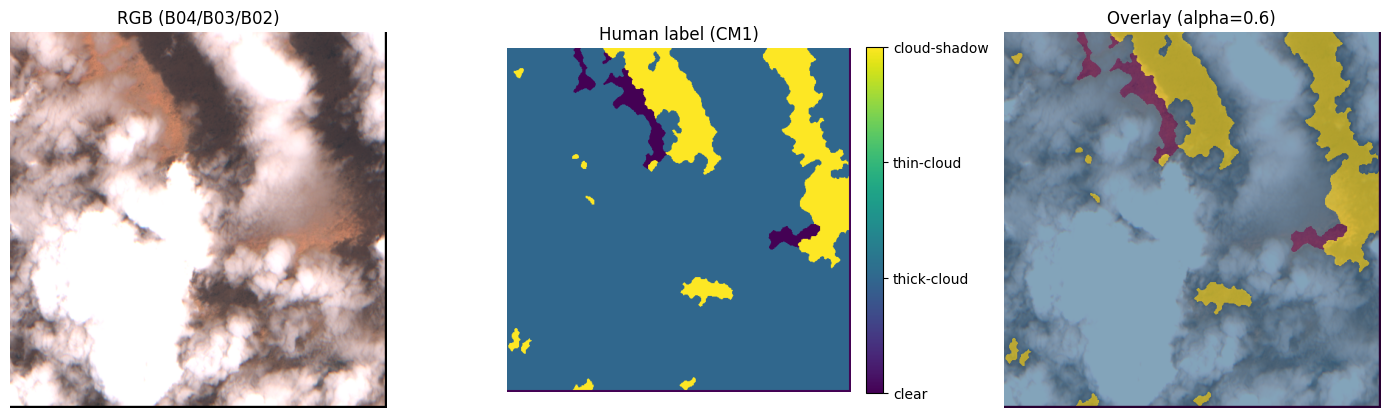

In [19]:
IDX = 88

print("datapoint_id:", val_df.iloc[IDX]["datapoint_id"])
datapoint = load_datapoint(val_df, IDX)
print("datapoint shape [C,H,W]:", datapoint.shape)

plot_rgb_mask_overlay(datapoint, alpha=0.6)

After `python export_p509_high_npz.py`

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA_ROOT = Path("../data/cloudsen12plus/export_p509_high_npz")
IMG_DIR = DATA_ROOT / "val" / "images"
MSK_DIR = DATA_ROOT / "val" / "masks"

assert IMG_DIR.exists(), IMG_DIR
assert MSK_DIR.exists(), MSK_DIR

img_files = sorted(IMG_DIR.glob("*.npz"))
msk_files = sorted(MSK_DIR.glob("*.npz"))

print("num val images:", len(img_files))
print("num val masks :", len(msk_files))
print("first image:", img_files[0].name)
print("first mask :", msk_files[0].name)

num val images: 535
num val masks : 535
first image: ROI_0009__20190513T180929_20190513T181344_T12SWH.npz
first mask : ROI_0009__20190513T180929_20190513T181344_T12SWH.npz


In [3]:
LABEL_NAMES = {0: "clear", 1: "thick-cloud", 2: "thin-cloud", 3: "cloud-shadow"}

def plot_rgb_mask_overlay(rgb_chw, mask_hw, alpha=0.45, figsize=(14,5)):
    """
    rgb_chw: float32 [3,H,W] in 0..1
    mask_hw: uint8  [H,W] with values 0..3
    """
    rgb = np.transpose(rgb_chw, (1, 2, 0))

    fig, ax = plt.subplots(1, 3, figsize=figsize)

    ax[0].imshow(rgb)
    ax[0].set_title("RGB")
    ax[0].axis("off")

    im = ax[1].imshow(mask_hw, vmin=0, vmax=3)
    ax[1].set_title("Mask")
    ax[1].axis("off")
    cbar = fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
    cbar.set_ticks([0,1,2,3])
    cbar.set_ticklabels([LABEL_NAMES[i] for i in [0,1,2,3]])

    ax[2].imshow(rgb)
    ax[2].imshow(mask_hw, vmin=0, vmax=3, alpha=alpha)
    ax[2].set_title(f"Overlay (alpha={alpha})")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

file: ROI_0257__20190807T105621_20190807T110748_T29PMT.npz
rgb: (3, 512, 512) float32 range: 0.0 1.0
mask: (512, 512) uint8 unique: [0 1 3]
label histogram: {0: 8955, 1: 222001, 3: 31188}


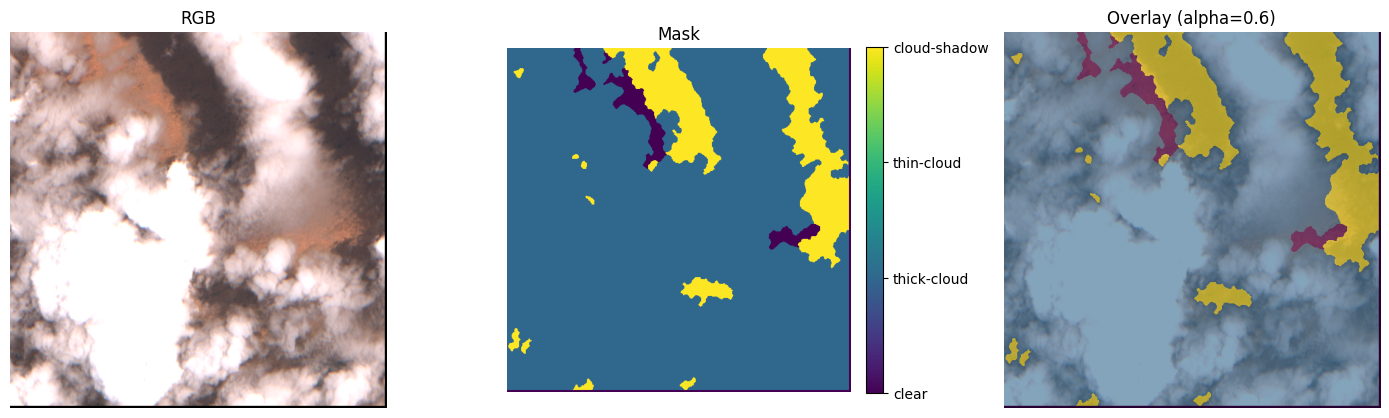

In [6]:
IDX = 88

img_path = img_files[IDX]
msk_path = MSK_DIR / img_path.name

img_npz = np.load(img_path)
msk_npz = np.load(msk_path)

rgb = img_npz["image"]
mask = msk_npz["mask"]

print("file:", img_path.name)
print("rgb:", rgb.shape, rgb.dtype, "range:", float(rgb.min()), float(rgb.max()))
print("mask:", mask.shape, mask.dtype, "unique:", np.unique(mask))

vals, cnts = np.unique(mask, return_counts=True)
print("label histogram:", {int(v): int(c) for v, c in zip(vals, cnts)})

plot_rgb_mask_overlay(rgb, mask, alpha=0.6)

This verifies that our export function works properly, and we successfully exported RGB channels and also the mask layer for fine–tuning.